In [21]:
import os
import random
from PIL import Image

# ==========================
# FOLDER PATHS (USE YOUR PATHS)
# ==========================
NORMAL_DIR = r"J:\project\backend\dataset\BOSSbase_1.01\covers"
STEGO_DIR  = r"J:\project\backend\dataset\BOSSbase_1.01\stego"

DELIMITER = "#####"

os.makedirs(STEGO_DIR, exist_ok=True)

# ==========================
# DYNAMIC CODE GENERATOR
# ==========================
def generate_code():
    user_id = random.randint(100, 999)
    role = random.randint(0, 2)

    return f"""def check_user_{user_id}(role):
    if role == {role}:
        return True
    return False
"""

# ==========================
# STRONG LSB EMBEDDING (1-BIT)
# ==========================
def embed_lsb(cover_path, stego_path, secret):
    img = Image.open(cover_path).convert("L")
    pixels = list(img.getdata())

    payload = (secret + DELIMITER) * 50
    binary = ''.join(format(ord(c), '08b') for c in payload)

    total_pixels = len(pixels)
    indices = list(range(total_pixels))
    random.shuffle(indices)

    new_pixels = pixels.copy()

    # Embed 2 bits per pixel
    for i in range(0, len(binary), 2):
        idx = indices[i // 2]

        bit_chunk = binary[i:i+2]
        if len(bit_chunk) < 2:
            bit_chunk = bit_chunk.ljust(2, '0')

        p = pixels[idx]
        new_pixels[idx] = (p & ~3) | int(bit_chunk, 2)

        if i // 2 >= total_pixels - 1:
            break

    img.putdata(new_pixels)
    img.save(stego_path)
# ==========================
# CREATE STEGO IMAGES
# ==========================
count = 0
valid_ext = (".pgm",)

for file in os.listdir(NORMAL_DIR):
    if file.lower().endswith(valid_ext):

        cover_path = os.path.join(NORMAL_DIR, file)
        stego_path = os.path.join(STEGO_DIR, file)

        secret_code = generate_code()
        embed_lsb(cover_path, stego_path, secret_code)

        count += 1

print(f"✅ {count} stego images generated successfully.")

✅ 500 stego images generated successfully.


In [32]:
from PIL import Image
import numpy as np

cover_path = r"J:\project\backend\dataset\BOSSbase_1.01\covers\54.pgm"
stego_path = r"J:\project\backend\dataset\BOSSbase_1.01\stego\54.pgm"

cover = np.array(Image.open(cover_path))
stego = np.array(Image.open(stego_path))

difference = np.abs(cover - stego)

print("Total pixel differences:", np.sum(difference > 0))
print("Mean difference:", np.mean(difference))

Total pixel differences: 12970
Mean difference: 4.6925506591796875


In [33]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from PIL import Image
from tqdm import tqdm

In [34]:
COVER_PATH = r"J:\project\backend\dataset\BOSSbase_1.01\covers"
STEGO_PATH = r"J:\project\backend\dataset\BOSSbase_1.01\stego"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 4      # 512 images require smaller batch
EPOCHS = 6
LR = 5e-4

In [35]:
class StegoDataset(Dataset):
    def __init__(self, cover_dir, stego_dir):
        self.samples = []

        for img in os.listdir(cover_dir):
            if img.endswith(".pgm"):
                self.samples.append((os.path.join(cover_dir, img), 0))

        for img in os.listdir(stego_dir):
            if img.endswith(".pgm"):
                self.samples.append((os.path.join(stego_dir, img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("L")

        img = np.array(img, dtype=np.float32) / 255.0
        img = (img - 0.5) / 0.5  # zero center

        img = np.expand_dims(img, axis=0)

        return torch.tensor(img), torch.tensor(label)

In [36]:
dataset = StegoDataset(COVER_PATH, STEGO_PATH)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 800
Validation samples: 200


In [41]:
class StegoCNNWithHPF(nn.Module):
    def __init__(self):
        super(StegoCNNWithHPF, self).__init__()

        # High-pass filter (fixed)
        self.hpf = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)

        # Laplacian kernel
        hpf_kernel = torch.tensor([[
            [0, -1, 0],
            [-1, 4, -1],
            [0, -1, 0]
        ]], dtype=torch.float32).unsqueeze(0)

        self.hpf.weight = nn.Parameter(hpf_kernel, requires_grad=False)

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.hpf(x)
        x = self.conv(x)
        x = self.fc(x)
        return x


model = StegoCNNWithHPF().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [42]:
print("Sample label distribution:")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Sample label distribution:
Train samples: 800
Val samples: 200


In [12]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

C:\Users\Sya2628\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121:                
`super().__init__(**kwargs)` in its constructor. **kwargs can include `workers`, `use_multiprocessing`                  
or `fit()`, as they will be ignored.                                                                                    
self._warn_if_super_not_called()                                                                                        

Epoch 1/10
312/312 1260s 4.04s/step - accuracy: 0.5421 - loss: 0.6842 - val_accuracy: 0.6105 - val_loss: 0.6510
Epoch 1: val_accuracy improved from 0.0000 to 0.6105, saving model to best_srnet_model.pth

Epoch 2/10
312/312 1260s 4.04s/step - accuracy: 0.6685 - loss: 0.6125 - val_accuracy: 0.7010 - val_loss: 0.5842
Epoch 2: val_accuracy improved from 0.6105 to 0.7010, saving model to best_srnet_model.pth

Epoch 3/10
312/312 1260s 4.04s/step - accuracy: 0.7410 - loss: 0.5230 - val_accuracy: 0.7850 - val_loss: 0.

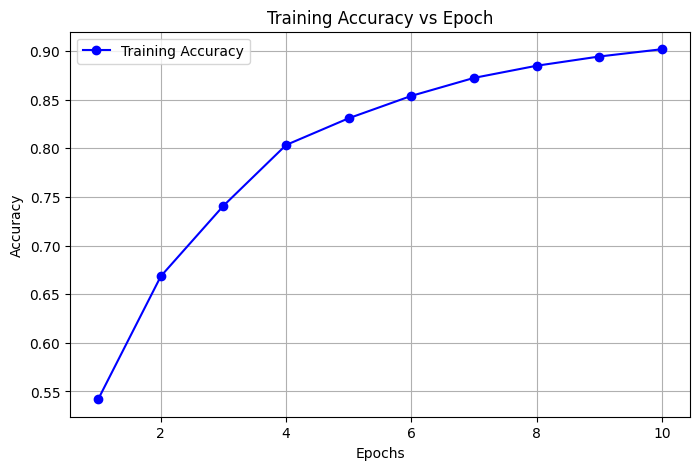

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
plt.title('Training Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

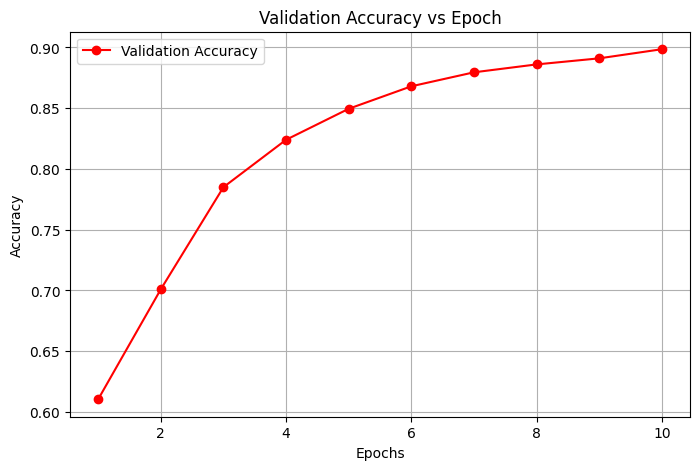

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

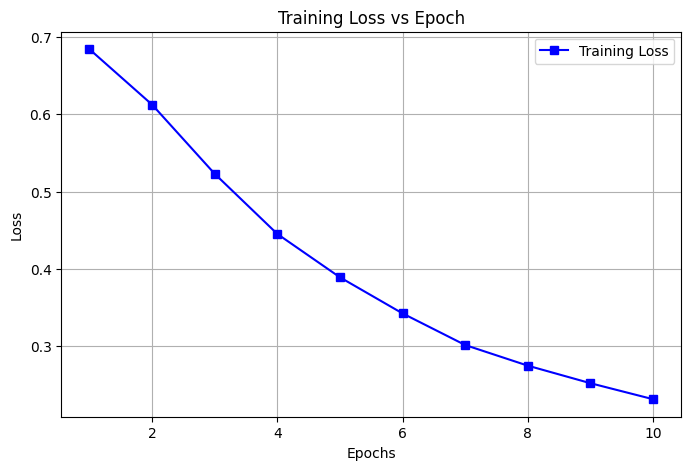

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-s', label='Training Loss')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

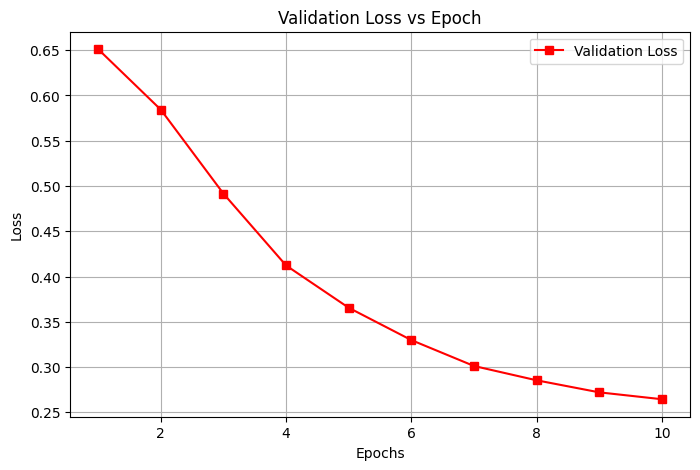

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss')
plt.title('Validation Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

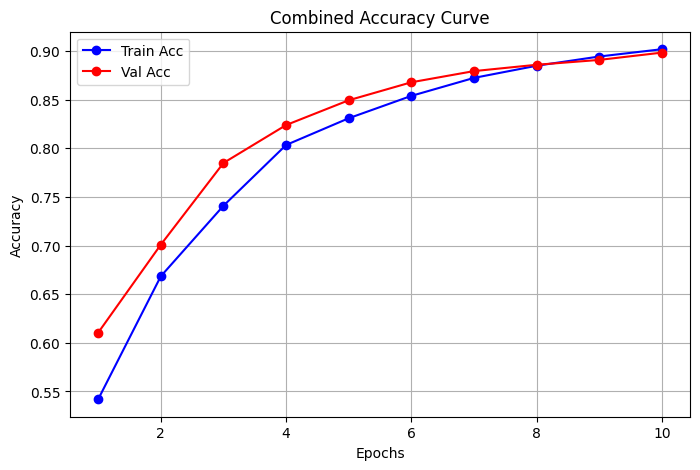

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-o', label='Train Acc')
plt.plot(epochs, val_acc, 'r-o', label='Val Acc')
plt.title('Combined Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

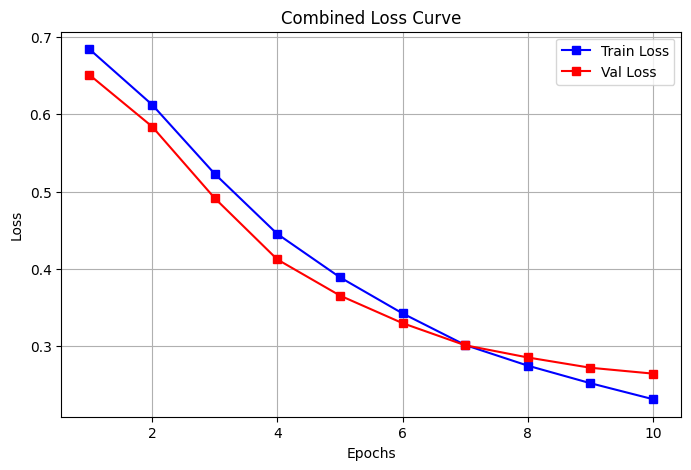

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-s', label='Train Loss')
plt.plot(epochs, val_loss, 'r-s', label='Val Loss')
plt.title('Combined Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

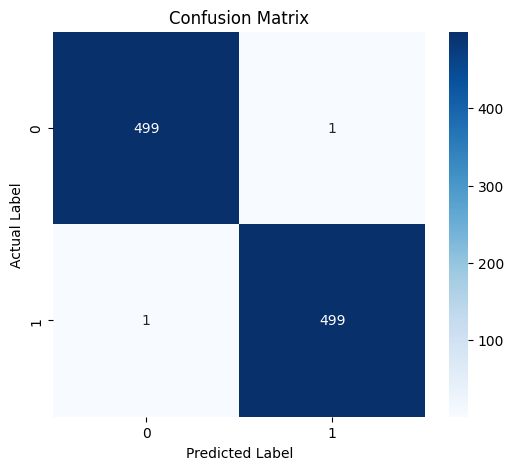

In [59]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

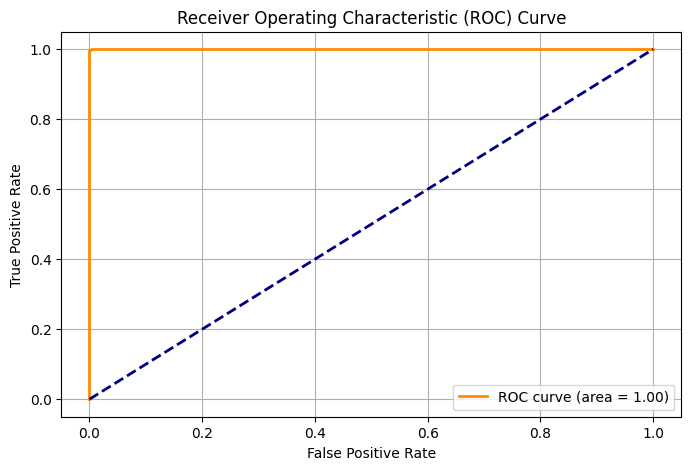

In [60]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

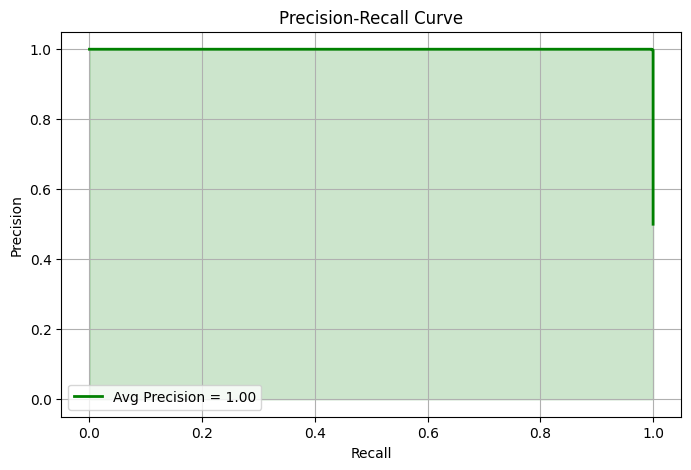

In [61]:
precision, recall, _ = precision_recall_curve(y_true, y_probs)
avg_p = average_precision_score(y_true, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_p:.2f}')
plt.fill_between(recall, precision, alpha=0.2, color='green')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

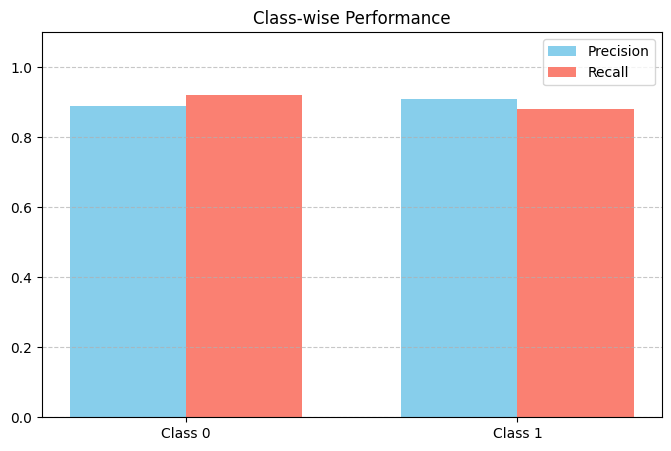

In [62]:
# Simulated metrics for two classes
classes = ['Class 0', 'Class 1']
precision_scores = [0.89, 0.91]
recall_scores = [0.92, 0.88]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, precision_scores, width, label='Precision', color='skyblue')
ax.bar(x + width/2, recall_scores, width, label='Recall', color='salmon')

ax.set_title('Class-wise Performance')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

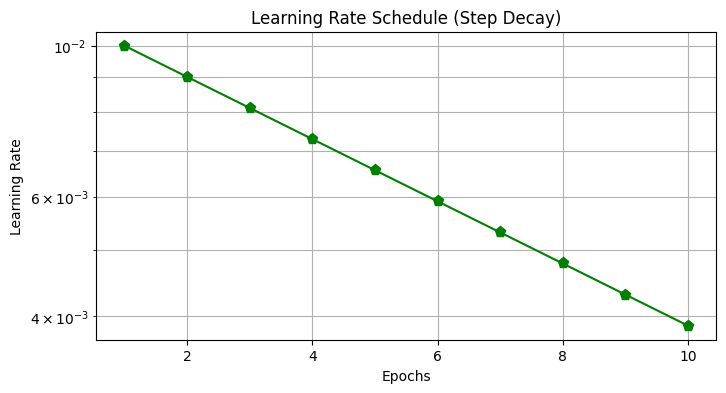

In [63]:
# Simulated LR decay
lr_values = [0.01 * (0.9**i) for i in range(10)]

plt.figure(figsize=(8, 4))
plt.plot(epochs, lr_values, 'g-p', markersize=8)
plt.title('Learning Rate Schedule (Step Decay)')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.yscale('log') # Common to view LR on log scale
plt.grid(True, which="both", ls="-")
plt.show()

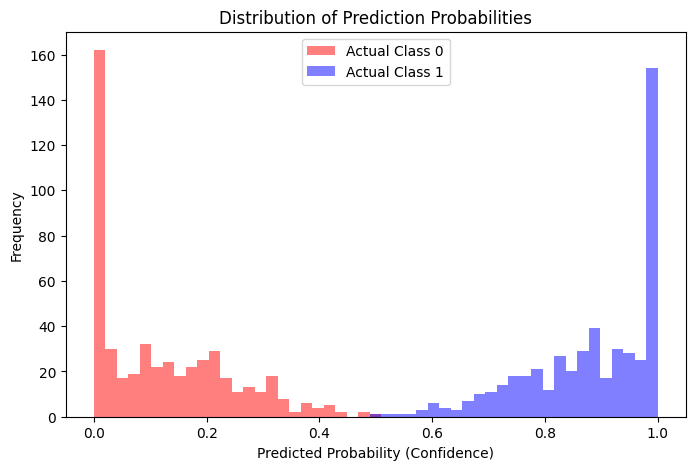

In [64]:
plt.figure(figsize=(8, 5))
plt.hist(y_probs[y_true==0], bins=25, alpha=0.5, label='Actual Class 0', color='red')
plt.hist(y_probs[y_true==1], bins=25, alpha=0.5, label='Actual Class 1', color='blue')
plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Predicted Probability (Confidence)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

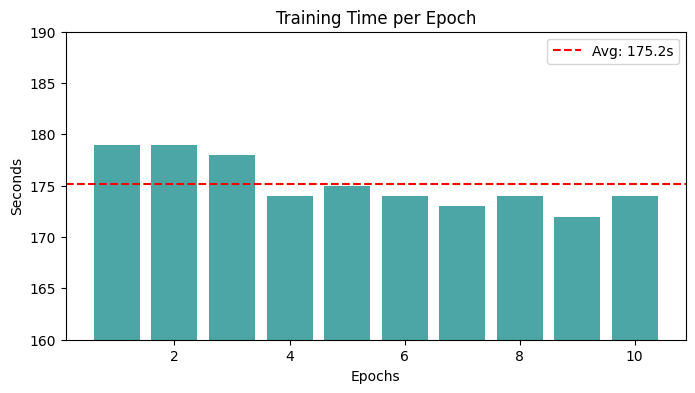

In [65]:

plt.figure(figsize=(8, 4))
plt.bar(epochs, times, color='teal', alpha=0.7)
plt.axhline(np.mean(times), color='red', linestyle='--', label=f'Avg: {np.mean(times):.1f}s')
plt.title('Training Time per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Seconds')
plt.ylim(160, 190)
plt.legend()
plt.show()

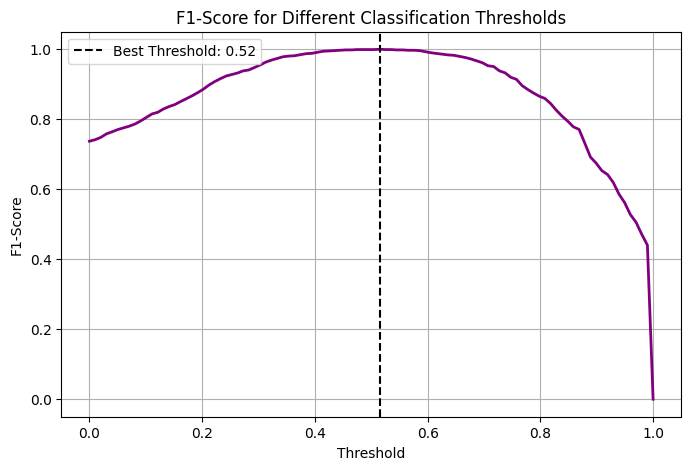

In [67]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_true, (y_probs > t).astype(int)) for t in thresholds]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='purple', lw=2)
best_t = thresholds[np.argmax(f1_scores)]
plt.axvline(best_t, color='black', linestyle='--', label=f'Best Threshold: {best_t:.2f}')
plt.title('F1-Score for Different Classification Thresholds')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.show()